# Geology & Shoreline Downloader — lithology + distance-to-coast

Stages two GAIA DataHub covariates used by the **gwl-space-time-smooth** hydrogeologic
domain mask (issue #2) and consumed downstream by LandLab landslide modelling:

| Output | What | Source |
|---|---|---|
| `lithology_90m.tif` | standardized lithology classes `0 unconsolidated · 1 fractured-bedrock · 2 young-volcanic · 3 CRBG` | [WA DNR surface geology](https://dnr.wa.gov/washington-geological-survey/publications-and-data/geology-gis-data-and-databases) (ArcGIS REST); [USGS SGMC](https://www.sciencebase.gov/catalog/item/5888bf4fe4b05ccb964bab9d) for CONUS backbone |
| `dist_coast_90m.tif` | metres to the marine shoreline | [NOAA Medium-Resolution Shoreline](https://shoreline.noaa.gov/data/datasheets/medres.html) (production); WA DNR `Water` polygons (demo) |

The notebook **confirms each download with a plot**, rasterizes to the canonical
**90 m EPSG:5070** grid, and writes the two GeoTIFFs plus the lithology crosswalk.
They are then published to the DataHub as STAC collections and consumed in the GWL repo
via `python -m src.data.fetch_gaia lithology` / `dist_coast`.

In [1]:
import json, math, time, urllib.request, urllib.parse
from pathlib import Path

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio import features
from rasterio.transform import from_origin
from scipy.ndimage import distance_transform_edt
from pyproj import Transformer

In [2]:
# ── Configuration ───────────────────────────────────────────────────────────
# Demo AOI: central Washington Cascades — spans alluvial valley fill, fractured
# Tertiary volcanic/sedimentary bedrock, and the High-Cascade volcanic front, so all
# lithology classes appear. Swap for any WA box (see the coverage note in §2).
AOI = (-121.6, 46.5, -120.6, 47.3)          # W, S, E, N (WGS84)
DX = 90.0                                    # m — canonical grid resolution
OUT = Path("data/geology_shoreline"); OUT.mkdir(parents=True, exist_ok=True)

# WA DNR surface geology (25k–99k) — layer 8 = Geologic Unit Polygons.
# Native SR is EPSG:2927 (WA State Plane South, ftUS); the REST spatial filter must be
# supplied in that SR, so we reproject the AOI envelope before querying.
REST = ("https://gis.dnr.wa.gov/site1/rest/services/Public_Geology/"
        "25_to_99k_Surface_Geology/MapServer/8/query")
to2927 = Transformer.from_crs("EPSG:4326", "EPSG:2927", always_xy=True)
print("AOI", AOI, "| output ->", OUT.resolve())

AOI (-121.6, 46.5, -120.6, 47.3) | output -> /Users/marinedenolle/GitHub/gaia-data-downloaders/data/geology_shoreline


## 1. Lithology from WA DNR surface geology

Query the geologic-unit polygons intersecting the AOI. The `AGE_LITHOLOGY` field is a
human-readable age + lithology label (e.g. *Quaternary alluvium*, *Tertiary volcanic
rocks*) — exactly what we crosswalk to the four hydrogeologic-relevant classes.

In [3]:
def fetch_geology(aoi, max_offset_deg=0.0005):
    """Page the WA DNR REST layer over `aoi`; return a GeoDataFrame (EPSG:4326)."""
    x0, y0 = to2927.transform(aoi[0], aoi[1])
    x1, y1 = to2927.transform(aoi[2], aoi[3])
    feats, offset = [], 0
    while True:
        params = {
            "where": "1=1",
            "geometry": f"{x0},{y0},{x1},{y1}", "geometryType": "esriGeometryEnvelope",
            "inSR": "2927", "outSR": "4326", "spatialRel": "esriSpatialRelIntersects",
            "outFields": "GUNIT_TXT,AGE_LITHOLOGY", "returnGeometry": "true",
            "maxAllowableOffset": str(max_offset_deg),   # thin vertices — fast download
            "resultOffset": str(offset), "resultRecordCount": "2000", "f": "geojson",
        }
        url = REST + "?" + urllib.parse.urlencode(params)
        with urllib.request.urlopen(url, timeout=120) as r:
            batch = json.load(r).get("features", [])
        feats += batch
        if len(batch) < 2000:
            break
        offset += 2000
    return gpd.GeoDataFrame.from_features(feats, crs="EPSG:4326")

t0 = time.time()
geo = fetch_geology(AOI)
print(f"fetched {len(geo)} polygons in {time.time()-t0:.0f}s")
geo["AGE_LITHOLOGY"].value_counts()

fetched 599 polygons in 0s


AGE_LITHOLOGY
Quaternary alluvium                                   149
Water                                                 148
Tertiary volcanic rocks                               104
Tertiary sedimentary rocks and deposits                81
Quaternary mass-wasting deposits                       40
Quaternary eolian deposits, loess                      34
Tertiary volcanic and sedimentary rocks                33
Quaternary-Tertiary sedimentary rocks and deposits      9
Quaternary volcanic rocks                               1
Name: count, dtype: int64

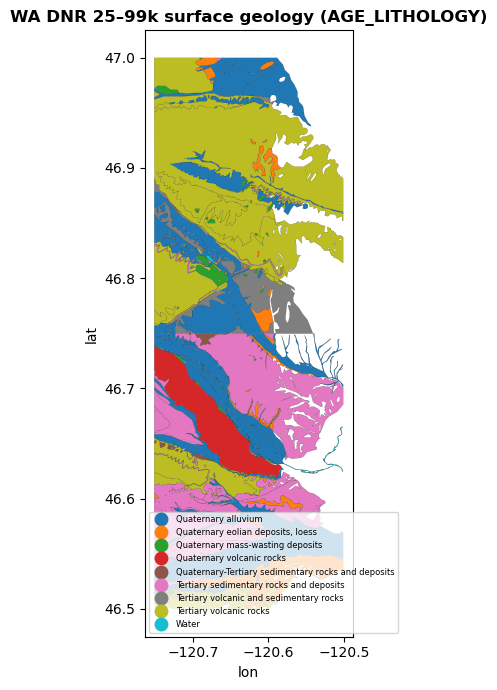

In [4]:
# ── Confirm the download: plot the raw geology ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
geo.plot(column="AGE_LITHOLOGY", legend=True, ax=ax, linewidth=0.1, edgecolor="k",
         legend_kwds={"fontsize": 6, "loc": "lower left"})
ax.set_title("WA DNR 25–99k surface geology (AGE_LITHOLOGY)", fontweight="bold")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
plt.tight_layout(); plt.show()

In [5]:
# ── Crosswalk AGE_LITHOLOGY -> hydrogeologic lithology class ─────────────────
# 0 unconsolidated | 1 fractured-bedrock | 2 young-volcanic | 3 CRBG | 255 water/nodata
# Priority order matters (CRBG and young-volcanic checked before the generic rules).
def lithology_class(label: str) -> int:
    t = (label or "").lower()
    if "water" in t:
        return 255
    if "columbia river basalt" in t or ("miocene" in t and "basalt" in t):
        return 3                                            # CRBG (confined basalt)
    if (("quaternary" in t or "holocene" in t)
            and any(k in t for k in ("volcan", "andesite")) and "tertiary" not in t):
        return 2                                            # young High-Cascade volcanics
    if any(k in t for k in ("alluvium", "glacial", "outwash", "till", "drift",
                            "eolian", "loess", "mass-wasting", "nonglacial", "terrace")):
        return 0                                            # unconsolidated
    return 1                                                # consolidated / fractured bedrock

geo["litho"] = geo["AGE_LITHOLOGY"].map(lithology_class)
CLASS_NAMES = {0: "unconsolidated", 1: "fractured-bedrock", 2: "young-volcanic",
               3: "CRBG", 255: "water/nodata"}
print({CLASS_NAMES[k]: int(v) for k, v in geo["litho"].value_counts().items()})

# Save the auditable crosswalk (distinct label -> class) for the consumer repo.
crosswalk = {lab: int(lithology_class(lab)) for lab in sorted(geo["AGE_LITHOLOGY"].dropna().unique())}
(OUT / "lithology_crosswalk.json").write_text(json.dumps(crosswalk, indent=2))
crosswalk

{'fractured-bedrock': 227, 'unconsolidated': 223, 'water/nodata': 148, 'young-volcanic': 1}


{'Quaternary alluvium': 0,
 'Quaternary eolian deposits, loess': 0,
 'Quaternary mass-wasting deposits': 0,
 'Quaternary volcanic rocks': 2,
 'Quaternary-Tertiary sedimentary rocks and deposits': 1,
 'Tertiary sedimentary rocks and deposits': 1,
 'Tertiary volcanic and sedimentary rocks': 1,
 'Tertiary volcanic rocks': 1,
 'Water': 255}

lithology grid (628, 329) classes [np.int16(0), np.int16(1), np.int16(2), np.int16(255)]


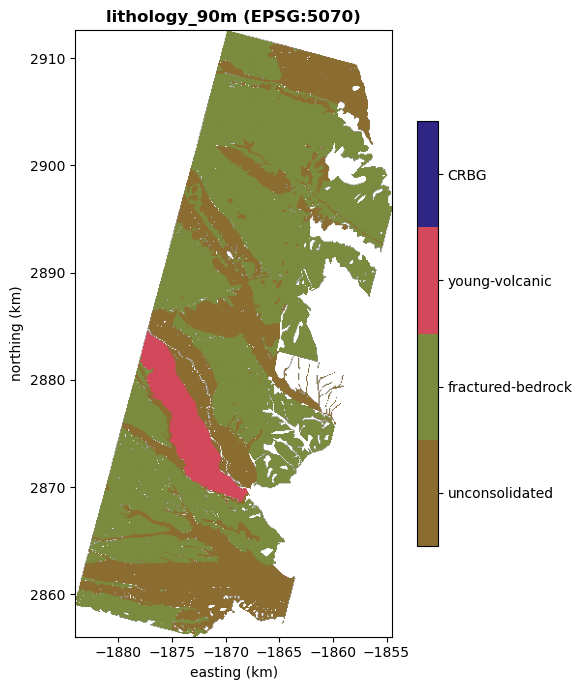

In [6]:
# ── Rasterize to the 90 m EPSG:5070 grid ────────────────────────────────────
g5070 = geo.to_crs(5070)
b = g5070.total_bounds
x0 = math.floor(b[0] / DX) * DX
y1 = math.ceil(b[3] / DX) * DX
nx = int(math.ceil((b[2] - x0) / DX))
ny = int(math.ceil((y1 - b[1]) / DX))
transform = from_origin(x0, y1, DX, DX)

lithology = features.rasterize(
    ((geom, val) for geom, val in zip(g5070.geometry, g5070["litho"])),
    out_shape=(ny, nx), transform=transform, fill=255, dtype="int16",
)
print("lithology grid", lithology.shape, "classes", sorted(np.unique(lithology)))

cmap = mcolors.ListedColormap(["#8c6d31", "#7b8b3f", "#d1495b", "#2e2585"])  # 0,1,2,3
fig, ax = plt.subplots(figsize=(6, 7))
ext = [x0/1000, (x0+nx*DX)/1000, (y1-ny*DX)/1000, y1/1000]
im = ax.imshow(np.ma.masked_equal(lithology, 255), origin="upper", extent=ext,
               cmap=cmap, vmin=-0.5, vmax=3.5)
cb = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3], shrink=0.7)
cb.ax.set_yticklabels(["unconsolidated", "fractured-bedrock", "young-volcanic", "CRBG"])
ax.set_title("lithology_90m (EPSG:5070)", fontweight="bold")
ax.set_xlabel("easting (km)"); ax.set_ylabel("northing (km)")
plt.tight_layout(); plt.show()

In [7]:
# ── Write lithology_90m.tif ─────────────────────────────────────────────────
prof = dict(driver="GTiff", height=ny, width=nx, count=1, dtype="uint8", nodata=255,
            crs="EPSG:5070", transform=transform, compress="LZW", tiled=True,
            blockxsize=256, blockysize=256)
with rasterio.open(OUT / "lithology_90m.tif", "w", **prof) as dst:
    dst.write(np.clip(lithology, 0, 255).astype("uint8"), 1)
    dst.update_tags(**{f"CLASS_{k}": v for k, v in CLASS_NAMES.items()})
print("wrote", OUT / "lithology_90m.tif")

wrote data/geology_shoreline/lithology_90m.tif


## 2. Distance to coast

`dist_coast` drives the `coastal` domain (water table pinned near sea level) and the
sea-level boundary condition. It is **derived**, not downloaded: rasterize a shoreline to
a sea mask and take a Euclidean distance transform.

> **Demo vs production.** This demo uses the geology `Water` polygons present in the AOI to
> illustrate the method. For the real coastal domain over Puget Sound use a **marine**
> shoreline — [NOAA Medium-Resolution Shoreline](https://shoreline.noaa.gov/data/datasheets/medres.html)
> (includes Puget Sound interior) — and restrict to marine water only. Also note the 25–99k
> service has irregular quad coverage; the statewide-complete product is the **100k GeMS
> geodatabase** (`ger_portal_surface_geology_100k.zip`), whose `GeoMaterial` field replaces
> the `AGE_LITHOLOGY` crosswalk used here.

water cells: 322 | max distance: 18.2 km


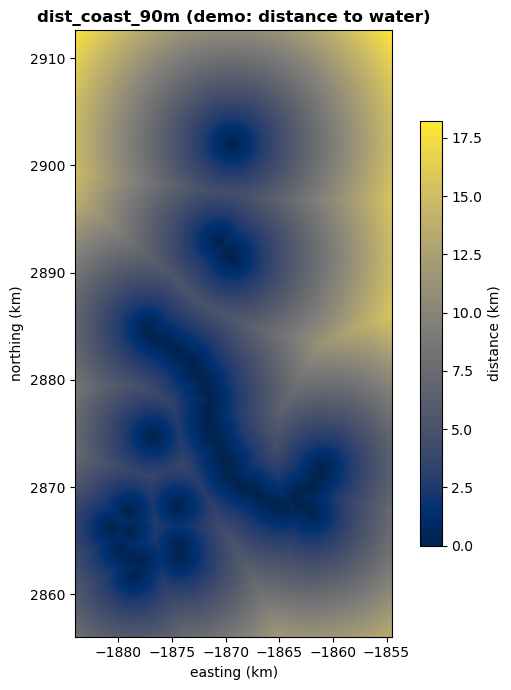

wrote data/geology_shoreline/dist_coast_90m.tif


In [8]:
# Marine mask from the 'Water' class (demo); distance transform -> metres.
water = g5070[g5070["AGE_LITHOLOGY"].str.lower().eq("water")]
sea = features.rasterize(((geom, 1) for geom in water.geometry),
                         out_shape=(ny, nx), transform=transform, fill=0, dtype="uint8")
dist_coast = distance_transform_edt(sea == 0) * DX           # metres
print("water cells:", int(sea.sum()), "| max distance:", round(dist_coast.max()/1000, 1), "km")

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(dist_coast / 1000, origin="upper", extent=ext, cmap="cividis")
plt.colorbar(im, ax=ax, label="distance (km)", shrink=0.7)
ax.set_title("dist_coast_90m (demo: distance to water)", fontweight="bold")
ax.set_xlabel("easting (km)"); ax.set_ylabel("northing (km)")
plt.tight_layout(); plt.show()

prof_f = {**prof, "dtype": "float32", "nodata": -9999.0}
with rasterio.open(OUT / "dist_coast_90m.tif", "w", **prof_f) as dst:
    dst.write(dist_coast.astype("float32"), 1)
print("wrote", OUT / "dist_coast_90m.tif")

## 3. Stage for the GAIA DataHub & hand off to the GWL model

Both rasters are now on the canonical 90 m EPSG:5070 grid. Publish them as DataHub STAC
collections (`lithology-stac`, `coastline-stac`) so every ecosystem project reuses them:

```python
# (DataHub publish step — pseudo)
#   odc.stac / rio-stac -> collection items -> s3://cresst/{lithology,coastline}-stac/
```

Then in **gwl-space-time-smooth** the consumer subcommands pull them and the classifier
builds the hydrogeologic-domain mask:

```bash
python -m src.data.fetch_gaia lithology   --bbox -124.9 42.0 -116.5 49.0
python -m src.data.fetch_gaia dist_coast  --bbox -124.9 42.0 -116.5 49.0
make domains          # -> hydrogeologic_domain_90m.tif (issue #2)
```

The same `lithology_90m` layer feeds the LandLab landslide study (fractured-upland regime),
which is why it lives here in the shared downloader rather than in any single model repo.